In [126]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
df=pd.read_csv("stock_data_50_records.csv")

In [128]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0
7,2026-01-13,109.53,111.44,107.88,NaN,69124.0
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0
9,2026-01-15,110.07,114.76,109.21,112.32,80764.0


In [129]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0


In [130]:
df.shape

(50, 6)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    50 non-null     object 
 1   Open    49 non-null     float64
 2   High    49 non-null     float64
 3   Low     50 non-null     float64
 4   Close   49 non-null     float64
 5   Volume  49 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.5+ KB


In [132]:
df.isnull().sum()

Date      0
Open      1
High      1
Low       0
Close     1
Volume    1
dtype: int64

In [133]:
df.describe().sum()

Open      6.519205e+02
High      6.668122e+02
Low       6.420069e+02
Close     6.550124e+02
Volume    1.381777e+06
dtype: float64

In [134]:
df=df.drop_duplicates()

In [135]:
df.duplicated().sum()

np.int64(0)

In [136]:
df["Open"].mean()

np.float64(99.5363043478261)

In [146]:
df["Open"] = df["Open"].fillna(df["Open"].mean())

In [147]:
df["High"]=df["High"].fillna(df["High"].mean())

In [148]:
df["Close"]=df["Close"].fillna(df["Close"].mean())

In [149]:
df["Volume"]=df["Volume"].fillna(df["Volume"].mean())

In [150]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Data      0
dtype: int64

In [151]:
df["Data"]=pd.to_datetime(df["Date"])

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 49
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    47 non-null     object        
 1   Open    47 non-null     float64       
 2   High    47 non-null     float64       
 3   Low     47 non-null     float64       
 4   Close   47 non-null     float64       
 5   Volume  47 non-null     float64       
 6   Data    47 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 2.9+ KB


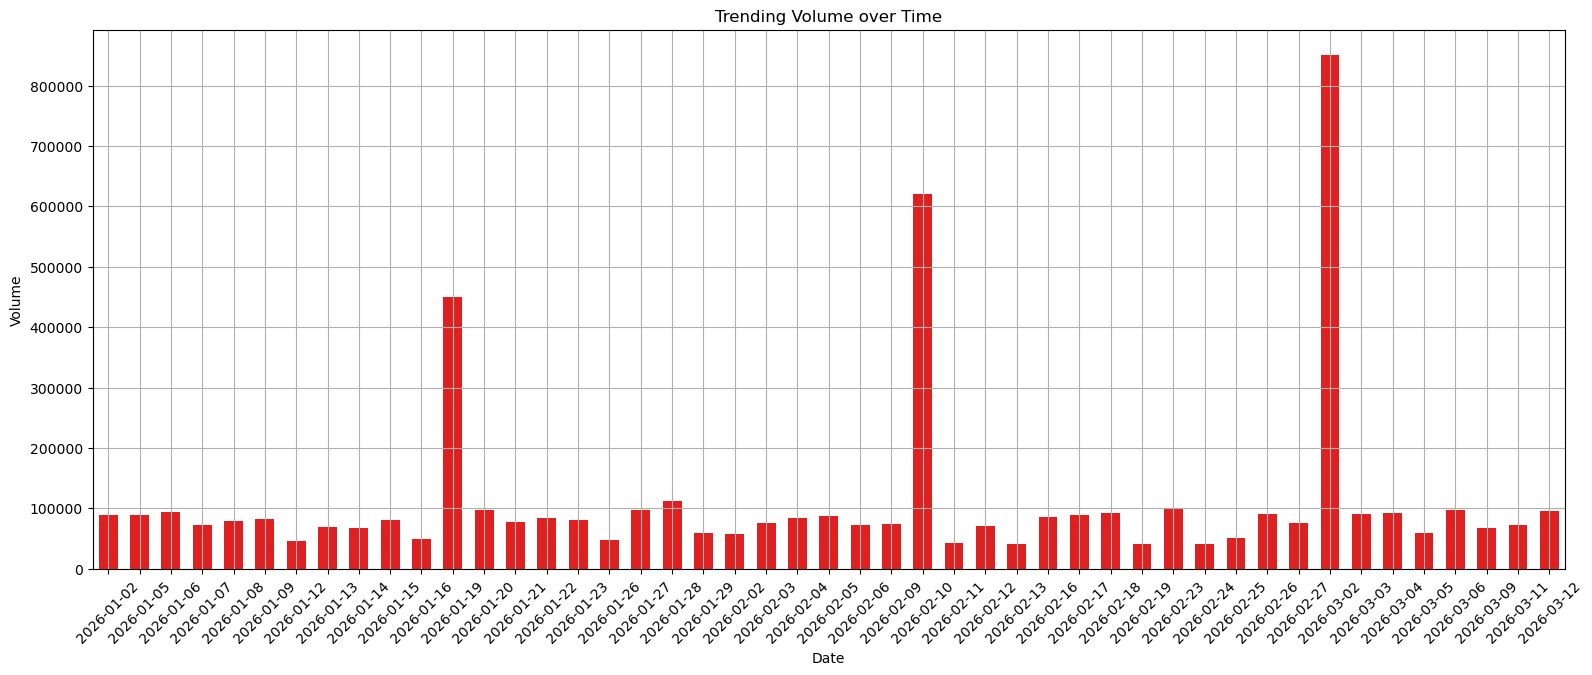

In [161]:
plt.figure(figsize=(19, 7))
sns.barplot(x="Date", y="Volume",data=df,width=0.6,color="Red")
plt.title("Trending Volume over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

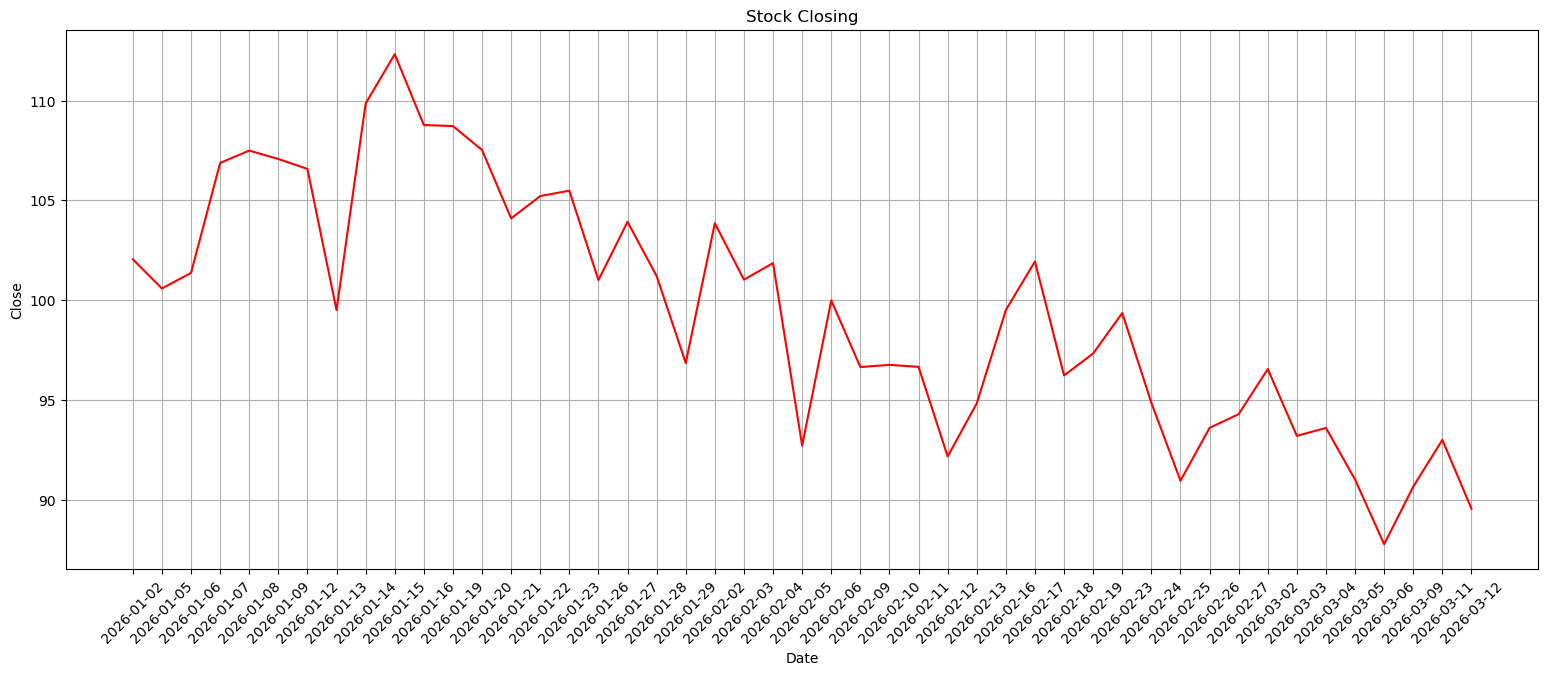

In [162]:
plt.figure(figsize=(19, 7))
sns.lineplot(x="Date", y="Close",data=df,color="Red")
plt.title("Stock Closing")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [163]:
correlation=df[["Open","High","Low","Close","Volume"]].corr()

In [164]:
correlation

,Open,High,Low,Close,Volume
Open,1.000000,0.963170,0.965165,0.901257,-0.053964
High,0.963170,1.000000,0.977360,0.949549,-0.039509
Low,0.965165,0.977360,1.000000,0.949401,-0.034648
Close,0.901257,0.949549,0.949401,1.000000,-0.003695
Volume,-0.053964,-0.039509,-0.034648,-0.003695,1.000000


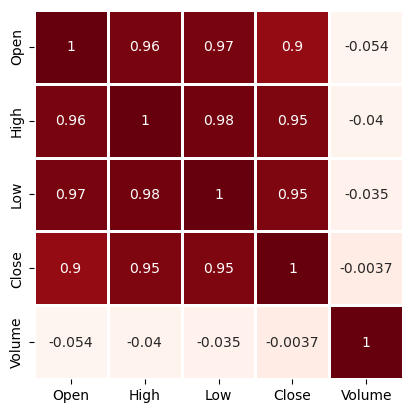

In [167]:
sns.heatmap(correlation,
            annot=True,cmap="Reds",
            cbar=False,
            square=True,
            linewidth=2)
plt.show()

In [168]:
df["Budgrt"]=df["Close"]
df["Actual"]=df["Open"]

  Department    Budget    Actual
0      Sales     50000     60000
1      Supra  20000000  30000000
2        BMW  25000000  35000000
3    finance     40000     60000
4     Shelby  20000000  33000000
5      Dodge  15000000  40000000
6        H2R   5000000   7000000
7  Marketing     70000     85000


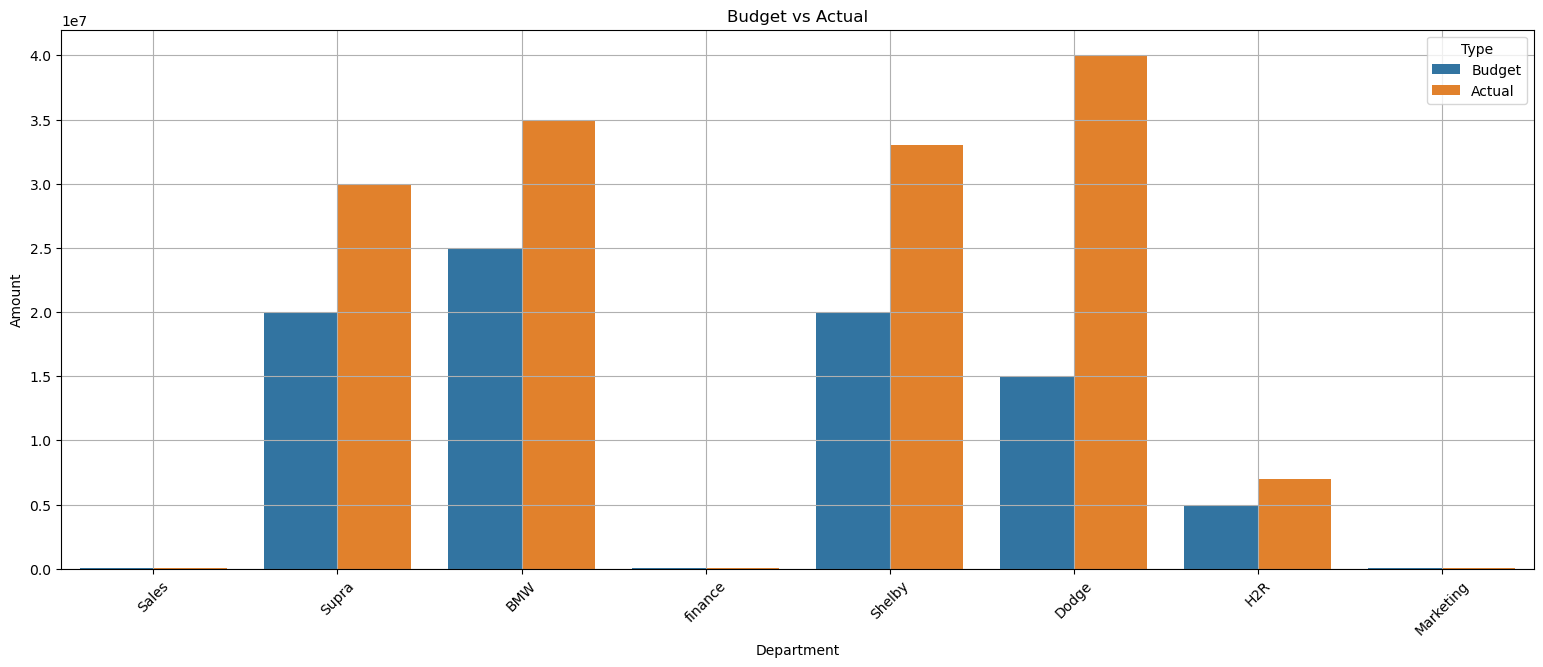

In [174]:
data={
    "Department":["Sales","Supra","BMW","finance","Shelby","Dodge","H2R","Marketing"],
    "Budget":[50000,20000000,25000000,40000,20000000,15000000,5000000,70000],
    "Actual":[60000,30000000,35000000,60000,33000000,40000000,7000000,85000]
}
df=pd.DataFrame(data)
print(df)

df_long=df.melt(
    id_vars="Department",
    value_vars=["Budget","Actual"],
    var_name="Type",
    value_name="Amount",
)    

plt.figure(figsize=(19, 7))
sns.barplot(data=df_long,x="Department", y="Amount",hue="Type")
plt.title("Budget vs Actual")
plt.xlabel("Department")
plt.ylabel("Amount")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()